<a href="https://colab.research.google.com/github/Ayush10web/KG_implementation_using_visual_transformer_for_theft-stealing_burglary_vandalism_detection-/blob/main/kg_ucf_crime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install torch torchvision transformers decord opencv-python numpy scikit-learn --break-system-packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 49.6 MB/s eta 0:00:00


In [ ]:
from transformers import VideoMAEImageProcessor, VideoMAEModel

processor = VideoMAEImageProcessor.from_pretrained("MCG-NJU/videomae-base")
model = VideoMAEModel.from_pretrained("MCG-NJU/videomae-base")
model.eval()

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/725 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  377MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

[transformers] VideoMAEModel LOAD REPORT from: MCG-NJU/videomae-base
Key                                                                  | Status     | 
---------------------------------------------------------------------+------------+-
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_after.bias             | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.intermediate.dense.weight        | UNEXPECTED | 
videomae.encoder.layer.{0...11}.attention.attention.q_bias           | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_before.weight          | UNEXPECTED | 
videomae.encoder.layer.{0...11}.attention.attention.v_bias           | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.intermediate.dense.bias          | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.output.dense.bias                | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.q_bias       | UNEXPECTED | 
encoder_to_decoder.weight                                            | UNEXPECTED

VideoMAEModel(
  (embeddings): VideoMAEEmbeddings(
    (patch_embeddings): VideoMAEPatchEmbeddings(
      (projection): Conv3d(3, 768, kernel_size=(2, 16, 16), stride=(2, 16, 16))
    )
  )
  (encoder): VideoMAEEncoder(
    (layer): ModuleList(
      (0-11): 12 x VideoMAELayer(
        (attention): VideoMAEAttention(
          (attention): VideoMAESelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): VideoMAESelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): VideoMAEIntermediate(
          (dense): Linear(in_features=768, out_features=3072, bias=True)
          (intermediate_act_fn): GELUActivation()
        )
        (output): VideoMAEOutput(
 

In [ ]:
def extract_video_features(video_path, model, processor, n_segments=32, frames_per_clip=16):
    frames = decord_load(video_path)  # get all frames
    segments = split_into_n_segments(frames, n_segments)
    features = []
    for seg in segments:
        clip = sample_frames(seg, frames_per_clip)   # 16 frames
        inputs = processor(list(clip), return_tensors="pt")
        with torch.no_grad():
            out = model(**inputs).last_hidden_state.mean(dim=1)  # pool to one vector
        features.append(out.squeeze(0))
    return torch.stack(features)  # shape: (32, hidden_dim)

In [ ]:
import torch
import torch.nn as nn
class MILHead(nn.Module):
    def __init__(self, in_dim=768):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(in_dim, 512), nn.ReLU(), nn.Dropout(0.6),
            nn.Linear(512, 32), nn.ReLU(), nn.Dropout(0.6),
            nn.Linear(32, 1), nn.Sigmoid()
        )
    def forward(self, x):  # x: (batch, 32, in_dim)
        return self.fc(x).squeeze(-1)  # (batch, 32) segment scores

In [ ]:
!pip install kagglehub --quiet

In [ ]:
import kagglehub
path = kagglehub.dataset_download("odins0n/ucf-crime-dataset")
print("Path to dataset files:", path)

Resuming download from 1984954368 bytes (9842326439 bytes left)...
Resuming download to /root/.cache/kagglehub/datasets/odins0n/ucf-crime-dataset/1.archive (1984954368/11827280807) bytes left.


100%|██████████| 11.0G/11.0G [08:55<00:00, 18.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/odins0n/ucf-crime-dataset/versions/1


In [ ]:
import os

count = 0
for root, dirs, filenames in os.walk(path):
    if not filenames:
        continue
    print(root, len(filenames), filenames[:3])
    count += 1
    if count > 10:
        break

/root/.cache/kagglehub/datasets/odins0n/ucf-crime-dataset/versions/1/Train/Explosion 18753 ['Explosion051_x264_340.png', 'Explosion046_x264_135870.png', 'Explosion046_x264_39370.png']
/root/.cache/kagglehub/datasets/odins0n/ucf-crime-dataset/versions/1/Train/Arrest 26397 ['Arrest047_x264_46810.png', 'Arrest047_x264_42990.png', 'Arrest047_x264_46870.png']
/root/.cache/kagglehub/datasets/odins0n/ucf-crime-dataset/versions/1/Train/Shooting 7140 ['Shooting025_x264_550.png', 'Shooting052_x264_3760.png', 'Shooting020_x264_2120.png']
/root/.cache/kagglehub/datasets/odins0n/ucf-crime-dataset/versions/1/Train/Vandalism 13626 ['Vandalism048_x264_4640.png', 'Vandalism011_x264_5340.png', 'Vandalism008_x264_11720.png']
/root/.cache/kagglehub/datasets/odins0n/ucf-crime-dataset/versions/1/Train/Abuse 19076 ['Abuse042_x264_2490.png', 'Abuse001_x264_2620.png', 'Abuse003_x264_1970.png']
/root/.cache/kagglehub/datasets/odins0n/ucf-crime-dataset/versions/1/Train/NormalVideos 947768 ['Normal_Videos451_x264

In [ ]:
import os
from collections import defaultdict

def build_video_index(class_folder):
    """Returns {video_name: sorted list of (frame_num, filepath)}"""
    videos = defaultdict(list)
    for fname in os.listdir(class_folder):
        if not fname.endswith(".png"):
            continue
        # e.g. "Vandalism048_x264_4640.png"
        name_part, frame_part = fname.rsplit("_x264_", 1)
        frame_num = int(frame_part.replace(".png", ""))
        videos[name_part].append((frame_num, os.path.join(class_folder, fname)))
    for k in videos:
        videos[k].sort(key=lambda x: x[0])  # sort by frame number
    return videos

vandalism_folder = f"{path}/Train/Vandalism"
vandalism_videos = build_video_index(vandalism_folder)

print(len(vandalism_videos), "videos found")
print(list(vandalism_videos.keys())[:5])
sample_vid = list(vandalism_videos.keys())[0]
print(sample_vid, "has", len(vandalism_videos[sample_vid]), "frames")

45 videos found
['Vandalism048', 'Vandalism011', 'Vandalism008', 'Vandalism005', 'Vandalism002']
Vandalism048 has 719 frames


In [ ]:
import numpy as np
from PIL import Image

def sample_frames_from_list(frame_list, n_segments=32, frames_per_clip=16):
    """frame_list: sorted list of (frame_num, filepath) for ONE video"""
    total = len(frame_list)
    if total < n_segments:
        return None  # too short, skip this video

    boundaries = np.linspace(0, total, n_segments + 1, dtype=int)
    clips = []
    for i in range(n_segments):
        start, end = boundaries[i], max(boundaries[i+1], boundaries[i] + 1)
        idx = np.linspace(start, end - 1, frames_per_clip, dtype=int)
        idx = np.clip(idx, 0, total - 1)
        clip_paths = [frame_list[j][1] for j in idx]
        clip_imgs = [Image.open(p).convert("RGB") for p in clip_paths]
        clips.append(clip_imgs)
    return clips  # list of n_segments, each a list of frames_per_clip PIL images

In [ ]:
def extract_video_features_from_frames(frame_list, model, processor, n_segments=32, frames_per_clip=16):
    clips = sample_frames_from_list(frame_list, n_segments, frames_per_clip)
    if clips is None:
        return None
    features = []
    for clip in clips:
        inputs = processor(clip, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            out = model(**inputs).last_hidden_state.mean(dim=1)
        features.append(out.squeeze(0).cpu())
    return torch.stack(features)

In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [ ]:
model = model.to(device)

In [ ]:
sample_vid = list(vandalism_videos.keys())[0]
feat = extract_video_features_from_frames(vandalism_videos[sample_vid], model, processor)
print(feat.shape)

torch.Size([32, 768])


In [ ]:
print(feat.shape)

torch.Size([32, 768])


In [ ]:
print(feat.mean(), feat.std())

tensor(0.0145) tensor(0.4804)


In [ ]:
import os
os.makedirs("/content/features", exist_ok=True)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
FEATURE_DIR = "/content/drive/MyDrive/ucf_features"
os.makedirs(FEATURE_DIR, exist_ok=True)

Mounted at /content/drive


In [ ]:
classes_to_use = ["Vandalism", "Stealing", "NormalVideos"]
n_samples_per_class = 5

all_video_indexes = {}
for cls in classes_to_use:
    folder = f"{path}/Train/{cls}"
    all_video_indexes[cls] = build_video_index(folder)
    print(cls, "total videos:", len(all_video_indexes[cls]))

Vandalism total videos: 45
Stealing total videos: 95
NormalVideos total videos: 800


In [ ]:
import time

def extract_and_cache(cls, video_dict, n_samples, feature_dir):
    video_names = list(video_dict.keys())[:n_samples]
    for vid_name in video_names:
        save_path = os.path.join(feature_dir, f"{cls}__{vid_name}.pt")
        if os.path.exists(save_path):
            print(f"skip (already done): {vid_name}")
            continue

        t0 = time.time()
        try:
            feat = extract_video_features_from_frames(video_dict[vid_name], model, processor)
        except Exception as e:
            print(f"FAILED: {vid_name} -> {e}")
            continue

        if feat is None:
            print(f"skip (too short): {vid_name}")
            continue

        torch.save(feat, save_path)
        print(f"done: {vid_name}  shape={tuple(feat.shape)}  time={time.time()-t0:.1f}s")

for cls in classes_to_use:
    extract_and_cache(cls, all_video_indexes[cls], n_samples_per_class, FEATURE_DIR)

done: Vandalism048  shape=(32, 768)  time=4.5s
done: Vandalism011  shape=(32, 768)  time=4.1s
done: Vandalism008  shape=(32, 768)  time=4.2s
done: Vandalism005  shape=(32, 768)  time=4.4s
done: Vandalism002  shape=(32, 768)  time=4.3s
done: Stealing077  shape=(32, 768)  time=4.2s
done: Stealing089  shape=(32, 768)  time=4.4s
done: Stealing092  shape=(32, 768)  time=4.5s
done: Stealing043  shape=(32, 768)  time=4.3s
done: Stealing086  shape=(32, 768)  time=4.4s
done: Normal_Videos451  shape=(32, 768)  time=4.7s
done: Normal_Videos078  shape=(32, 768)  time=4.4s
done: Normal_Videos354  shape=(32, 768)  time=4.5s
done: Normal_Videos543  shape=(32, 768)  time=5.3s
done: Normal_Videos187  shape=(32, 768)  time=4.6s


In [ ]:
saved_files = os.listdir(FEATURE_DIR)
print(len(saved_files), "features cached")
print(saved_files[:5])

15 features cached
['Vandalism__Vandalism048.pt', 'Vandalism__Vandalism011.pt', 'Vandalism__Vandalism008.pt', 'Vandalism__Vandalism005.pt', 'Vandalism__Vandalism002.pt']


In [ ]:
n_samples_per_class = 100  # adjust based on how many exist per class

for cls in classes_to_use:
    extract_and_cache(cls, all_video_indexes[cls], n_samples_per_class, FEATURE_DIR)

skip (already done): Vandalism048
skip (already done): Vandalism011
skip (already done): Vandalism008
skip (already done): Vandalism005
skip (already done): Vandalism002
done: Vandalism003  shape=(32, 768)  time=4.3s
done: Vandalism043  shape=(32, 768)  time=4.5s
done: Vandalism047  shape=(32, 768)  time=4.5s
done: Vandalism016  shape=(32, 768)  time=4.3s
done: Vandalism045  shape=(32, 768)  time=4.5s
done: Vandalism050  shape=(32, 768)  time=4.6s
done: Vandalism025  shape=(32, 768)  time=4.5s
done: Vandalism037  shape=(32, 768)  time=4.8s
done: Vandalism041  shape=(32, 768)  time=4.7s
done: Vandalism046  shape=(32, 768)  time=4.4s
done: Vandalism018  shape=(32, 768)  time=6.0s
done: Vandalism039  shape=(32, 768)  time=7.2s
done: Vandalism024  shape=(32, 768)  time=5.3s
done: Vandalism042  shape=(32, 768)  time=6.0s
done: Vandalism021  shape=(32, 768)  time=5.4s
done: Vandalism044  shape=(32, 768)  time=5.0s
done: Vandalism049  shape=(32, 768)  time=6.1s
done: Vandalism023  shape=(32, 

In [ ]:
import glob
import random
from torch.utils.data import Dataset, DataLoader

class MILVideoDataset(Dataset):
    def __init__(self, feature_dir, anomaly_classes, normal_class="NormalVideos"):
        self.anomaly_files = []
        self.normal_files = []
        for f in glob.glob(os.path.join(feature_dir, "*.pt")):
            fname = os.path.basename(f)
            cls = fname.split("__")[0]
            if cls == normal_class:
                self.normal_files.append(f)
            elif cls in anomaly_classes:
                self.anomaly_files.append(f)
        print(f"anomaly bags: {len(self.anomaly_files)}, normal bags: {len(self.normal_files)}")

    def __len__(self):
        return min(len(self.anomaly_files), len(self.normal_files))

    def __getitem__(self, idx):
        anom_feat = torch.load(self.anomaly_files[idx])
        norm_feat = torch.load(random.choice(self.normal_files))
        return anom_feat, norm_feat

dataset = MILVideoDataset(FEATURE_DIR, anomaly_classes=["Vandalism", "Stealing"])
loader = DataLoader(dataset, batch_size=4, shuffle=True)

anomaly bags: 140, normal bags: 100


In [29]:
def mil_ranking_loss(anom_scores, norm_scores, lambda1=8e-5, lambda2=8e-5):
    # anom_scores, norm_scores: (batch, 32)
    anom_max = anom_scores.max(dim=1)[0]   # (batch,)
    norm_max = norm_scores.max(dim=1)[0]   # (batch,)

    # Hinge ranking loss: anomalous max should exceed normal max by margin 1
    ranking_loss = torch.clamp(1 - anom_max + norm_max, min=0).mean()

    # Temporal smoothness: adjacent segment scores shouldn't jump wildly
    smoothness = ((anom_scores[:, 1:] - anom_scores[:, :-1]) ** 2).sum(dim=1).mean()

    # Sparsity: only a few segments should be anomalous, not the whole bag
    sparsity = anom_scores.sum(dim=1).mean()

    return ranking_loss + lambda1 * smoothness + lambda2 * sparsity

In [32]:
model_mil = MILHead(in_dim=768).to(device)
optimizer = torch.optim.Adagrad(model_mil.parameters(), lr=0.001)

n_epochs = 100
for epoch in range(n_epochs):
    total_loss = 0
    for anom_feat, norm_feat in loader:
        anom_feat, norm_feat = anom_feat.to(device), norm_feat.to(device)

        anom_scores = model_mil(anom_feat)   # (batch, 32)
        norm_scores = model_mil(norm_feat)   # (batch, 32)

        loss = mil_ranking_loss(anom_scores, norm_scores)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{n_epochs}  loss={total_loss/len(loader):.4f}")

Epoch 1/100  loss=0.9937
Epoch 2/100  loss=0.9818
Epoch 3/100  loss=0.9795
Epoch 4/100  loss=0.9671
Epoch 5/100  loss=0.9518
Epoch 6/100  loss=0.9362
Epoch 7/100  loss=0.9230
Epoch 8/100  loss=0.9103
Epoch 9/100  loss=0.9100
Epoch 10/100  loss=0.8876
Epoch 11/100  loss=0.8845
Epoch 12/100  loss=0.8704
Epoch 13/100  loss=0.8507
Epoch 14/100  loss=0.8564
Epoch 15/100  loss=0.8223
Epoch 16/100  loss=0.8243
Epoch 17/100  loss=0.8053
Epoch 18/100  loss=0.8033
Epoch 19/100  loss=0.8166
Epoch 20/100  loss=0.7714
Epoch 21/100  loss=0.7935
Epoch 22/100  loss=0.7680
Epoch 23/100  loss=0.7642
Epoch 24/100  loss=0.7442
Epoch 25/100  loss=0.7502
Epoch 26/100  loss=0.7401
Epoch 27/100  loss=0.7264
Epoch 28/100  loss=0.7124
Epoch 29/100  loss=0.7318
Epoch 30/100  loss=0.7154
Epoch 31/100  loss=0.7140
Epoch 32/100  loss=0.7164
Epoch 33/100  loss=0.7022
Epoch 34/100  loss=0.6846
Epoch 35/100  loss=0.7023
Epoch 36/100  loss=0.6808
Epoch 37/100  loss=0.6910
Epoch 38/100  loss=0.6849
Epoch 39/100  loss=0.

In [33]:
torch.save(model_mil.state_dict(), "/content/drive/MyDrive/ucf_features/mil_head.pt")

In [34]:
model_mil.eval()

test_vid_name = list(all_video_indexes["Vandalism"].keys())[10]  # one beyond your first 5-10 used
test_feat = extract_video_features_from_frames(all_video_indexes["Vandalism"][test_vid_name], model, processor)

with torch.no_grad():
    scores = model_mil(test_feat.unsqueeze(0).to(device)).squeeze(0).cpu().numpy()

print(test_vid_name)
for i, s in enumerate(scores):
    print(f"segment {i:2d}: {s:.3f}")

Vandalism050
segment  0: 0.775
segment  1: 0.785
segment  2: 0.812
segment  3: 0.771
segment  4: 0.788
segment  5: 0.682
segment  6: 0.698
segment  7: 0.684
segment  8: 0.732
segment  9: 0.662
segment 10: 0.677
segment 11: 0.753
segment 12: 0.712
segment 13: 0.696
segment 14: 0.707
segment 15: 0.750
segment 16: 0.678
segment 17: 0.728
segment 18: 0.705
segment 19: 0.789
segment 20: 0.723
segment 21: 0.709
segment 22: 0.762
segment 23: 0.783
segment 24: 0.750
segment 25: 0.749
segment 26: 0.779
segment 27: 0.767
segment 28: 0.767
segment 29: 0.758
segment 30: 0.792
segment 31: 0.744


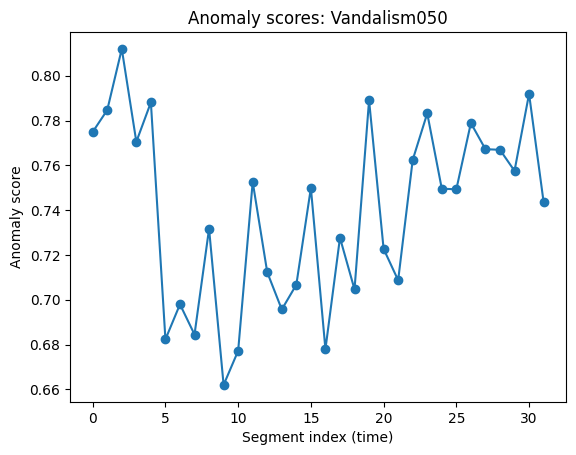

In [35]:
import matplotlib.pyplot as plt
plt.plot(scores, marker='o')
plt.xlabel("Segment index (time)")
plt.ylabel("Anomaly score")
plt.title(f"Anomaly scores: {test_vid_name}")
plt.show()

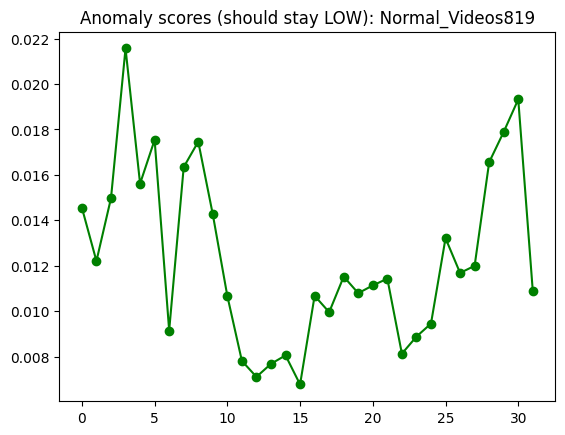

In [36]:
test_normal_name = list(all_video_indexes["NormalVideos"].keys())[10]
test_normal_feat = extract_video_features_from_frames(all_video_indexes["NormalVideos"][test_normal_name], model, processor)

with torch.no_grad():
    normal_scores = model_mil(test_normal_feat.unsqueeze(0).to(device)).squeeze(0).cpu().numpy()

plt.plot(normal_scores, marker='o', color='green')
plt.title(f"Anomaly scores (should stay LOW): {test_normal_name}")
plt.show()

In [37]:
import os
print("Train classes:", os.listdir(f"{path}/Train"))
print("Test classes:", os.listdir(f"{path}/Test"))

Train classes: ['Explosion', 'Arrest', 'Shooting', 'Vandalism', 'Abuse', 'NormalVideos', 'Burglary', 'Assault', 'Stealing', 'Robbery', 'Fighting', 'Arson', 'RoadAccidents', 'Shoplifting']
Test classes: ['Explosion', 'Arrest', 'Shooting', 'Vandalism', 'Abuse', 'NormalVideos', 'Burglary', 'Assault', 'Stealing', 'Robbery', 'Fighting', 'Arson', 'RoadAccidents', 'Shoplifting']


In [38]:
classes_to_use = ["Vandalism", "Stealing", "Robbery", "Burglary", "Shoplifting"]
normal_class = "NormalVideos"

all_video_indexes = {}
for cls in classes_to_use + [normal_class]:
    folder = f"{path}/Train/{cls}"
    all_video_indexes[cls] = build_video_index(folder)
    print(cls, "total videos:", len(all_video_indexes[cls]))

Vandalism total videos: 45
Stealing total videos: 95
Robbery total videos: 145
Burglary total videos: 87
Shoplifting total videos: 29
NormalVideos total videos: 800


In [39]:
import random

def train_test_split_videos(video_dict, test_frac=0.2, seed=42):
    names = list(video_dict.keys())
    random.Random(seed).shuffle(names)
    n_test = int(len(names) * test_frac)
    return names[n_test:], names[:n_test]

splits = {}
for cls in classes_to_use + [normal_class]:
    train_names, test_names = train_test_split_videos(all_video_indexes[cls])
    splits[cls] = {"train": train_names, "test": test_names}
    print(cls, "train:", len(train_names), "test:", len(test_names))

Vandalism train: 36 test: 9
Stealing train: 76 test: 19
Robbery train: 116 test: 29
Burglary train: 70 test: 17
Shoplifting train: 24 test: 5
NormalVideos train: 640 test: 160


In [40]:
n_train_per_class = 40
n_test_per_class = 10

for cls in classes_to_use + [normal_class]:
    n_needed = n_train_per_class if cls != normal_class else n_train_per_class * len(classes_to_use)
    names_to_extract = splits[cls]["train"][:n_needed]
    subset_dict = {n: all_video_indexes[cls][n] for n in names_to_extract}
    extract_and_cache(cls, subset_dict, len(subset_dict), FEATURE_DIR)

for cls in classes_to_use + [normal_class]:
    n_needed = n_test_per_class if cls != normal_class else n_test_per_class * len(classes_to_use)
    names_to_extract = splits[cls]["test"][:n_needed]
    subset_dict = {n: all_video_indexes[cls][n] for n in names_to_extract}
    extract_and_cache(cls, subset_dict, len(subset_dict), FEATURE_DIR)

skip (already done): Vandalism005
skip (already done): Vandalism038
skip (already done): Vandalism002
skip (already done): Vandalism032
skip (already done): Vandalism029
skip (already done): Vandalism025
skip (already done): Vandalism013
skip (already done): Vandalism033
skip (already done): Vandalism012
skip (already done): Vandalism026
skip (already done): Vandalism019
skip (already done): Vandalism041
skip (already done): Vandalism031
skip (already done): Vandalism044
skip (already done): Vandalism023
skip (already done): Vandalism030
skip (already done): Vandalism040
skip (already done): Vandalism048
skip (already done): Vandalism021
skip (already done): Vandalism039
skip (already done): Vandalism014
skip (already done): Vandalism022
skip (already done): Vandalism035
skip (already done): Vandalism009
skip (already done): Vandalism008
skip (already done): Vandalism001
skip (already done): Vandalism003
skip (already done): Vandalism034
skip (already done): Vandalism043
skip (already 

In [42]:
import glob, os

for f in glob.glob(os.path.join(FEATURE_DIR, "*.pt")):
    fname = os.path.basename(f)
    if "__" not in fname:
        print("bad file:", fname)

bad file: mil_head.pt


In [44]:
CHECKPOINT_DIR = "/content/drive/MyDrive/ucf_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
# save models there instead of FEATURE_DIR

In [46]:
class MILVideoDataset(Dataset):
    def __init__(self, feature_dir, anomaly_classes, allowed_names_by_class, normal_class="NormalVideos"):
        self.anomaly_files = []
        self.normal_files = []
        for f in glob.glob(os.path.join(feature_dir, "*.pt")):
            fname = os.path.basename(f)
            if "__" not in fname:
                continue  # skip non-feature files like model checkpoints
            cls, vid_name = fname.replace(".pt", "").split("__", 1)
            allowed = allowed_names_by_class.get(cls, [])
            if vid_name not in allowed:
                continue
            if cls == normal_class:
                self.normal_files.append(f)
            elif cls in anomaly_classes:
                self.anomaly_files.append(f)
        print(f"anomaly bags: {len(self.anomaly_files)}, normal bags: {len(self.normal_files)}")

    def __len__(self):
        return min(len(self.anomaly_files), len(self.normal_files))

    def __getitem__(self, idx):
        anom_feat = torch.load(self.anomaly_files[idx])
        norm_feat = torch.load(random.choice(self.normal_files))
        return anom_feat, norm_feat

In [49]:
import glob
from torch.utils.data import Dataset, DataLoader

class MILVideoDataset(Dataset):
    def __init__(self, feature_dir, anomaly_classes, allowed_names_by_class, normal_class="NormalVideos"):
        self.anomaly_files = []
        self.normal_files = []
        for f in glob.glob(os.path.join(feature_dir, "*.pt")):
            fname = os.path.basename(f)
            if "__" not in fname:
                continue
            cls, vid_name = fname.replace(".pt", "").split("__", 1)
            allowed = allowed_names_by_class.get(cls, [])
            if vid_name not in allowed:
                continue
            if cls == normal_class:
                self.normal_files.append(f)
            elif cls in anomaly_classes:
                self.anomaly_files.append(f)
        print(f"anomaly bags: {len(self.anomaly_files)}, normal bags: {len(self.normal_files)}")

    def __len__(self):
        return min(len(self.anomaly_files), len(self.normal_files))

    def __getitem__(self, idx):
        anom_feat = torch.load(self.anomaly_files[idx])
        norm_feat = torch.load(random.choice(self.normal_files))
        return anom_feat, norm_feat

In [50]:
train_allowed = {cls: splits[cls]["train"] for cls in classes_to_use + [normal_class]}
train_dataset = MILVideoDataset(FEATURE_DIR, classes_to_use, train_allowed, normal_class)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

anomaly bags: 216, normal bags: 260


In [52]:
model_mil = MILHead(in_dim=768).to(device)
optimizer = torch.optim.Adagrad(model_mil.parameters(), lr=0.001)

n_epochs = 100
for epoch in range(n_epochs):
    total_loss = 0
    for anom_feat, norm_feat in train_loader:
        anom_feat, norm_feat = anom_feat.to(device), norm_feat.to(device)
        anom_scores = model_mil(anom_feat)
        norm_scores = model_mil(norm_feat)
        loss = mil_ranking_loss(anom_scores, norm_scores)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}  loss={total_loss/len(train_loader):.4f}")

torch.save(model_mil.state_dict(), f"{CHECKPOINT_DIR}/mil_head_5class.pt")

Epoch 10/100  loss=0.9136
Epoch 20/100  loss=0.8379
Epoch 30/100  loss=0.7928
Epoch 40/100  loss=0.7608
Epoch 50/100  loss=0.7027
Epoch 60/100  loss=0.6682
Epoch 70/100  loss=0.6206
Epoch 80/100  loss=0.6157
Epoch 90/100  loss=0.6126
Epoch 100/100  loss=0.5764


In [53]:
from sklearn.metrics import roc_auc_score
import numpy as np

model_mil.eval()
y_true, y_score, y_class = [], [], []

for cls in classes_to_use + [normal_class]:
    n_needed = n_test_per_class if cls != normal_class else n_test_per_class * len(classes_to_use)
    for vid_name in splits[cls]["test"][:n_needed]:
        fpath = os.path.join(FEATURE_DIR, f"{cls}__{vid_name}.pt")
        if not os.path.exists(fpath):
            continue
        feat = torch.load(fpath).unsqueeze(0).to(device)
        with torch.no_grad():
            score = model_mil(feat).max().item()
        y_score.append(score)
        y_true.append(0 if cls == normal_class else 1)
        y_class.append(cls)

y_true, y_score, y_class = np.array(y_true), np.array(y_score), np.array(y_class)
overall_auc = roc_auc_score(y_true, y_score)
print("Overall AUC:", overall_auc)

normal_mask = y_class == normal_class
for cls in classes_to_use:
    cls_mask = y_class == cls
    mask = cls_mask | normal_mask
    if mask.sum() > 0:
        cls_auc = roc_auc_score(y_true[mask], y_score[mask])
        print(f"{cls} vs Normal AUC: {cls_auc:.3f}")

Overall AUC: 0.7566287878787878
Vandalism vs Normal AUC: 0.806
Stealing vs Normal AUC: 0.910
Robbery vs Normal AUC: 0.640
Burglary vs Normal AUC: 0.690
Shoplifting vs Normal AUC: 0.729


In [54]:
class SingleClassMILDataset(Dataset):
    def __init__(self, feature_dir, anomaly_class, allowed_names_by_class, normal_class="NormalVideos"):
        self.anomaly_files = []
        self.normal_files = []
        for f in glob.glob(os.path.join(feature_dir, "*.pt")):
            fname = os.path.basename(f)
            if "__" not in fname:
                continue
            cls, vid_name = fname.replace(".pt", "").split("__", 1)
            allowed = allowed_names_by_class.get(cls, [])
            if vid_name not in allowed:
                continue
            if cls == normal_class:
                self.normal_files.append(f)
            elif cls == anomaly_class:
                self.anomaly_files.append(f)
        print(f"[{anomaly_class}] anomaly bags: {len(self.anomaly_files)}, normal bags: {len(self.normal_files)}")

    def __len__(self):
        return min(len(self.anomaly_files), len(self.normal_files))

    def __getitem__(self, idx):
        anom_feat = torch.load(self.anomaly_files[idx])
        norm_feat = torch.load(random.choice(self.normal_files))
        return anom_feat, norm_feat

In [58]:
train_allowed = {cls: splits[cls]["train"] for cls in classes_to_use + [normal_class]}
per_class_models = {}

for cls in classes_to_use:
    print(f"\n=== Training MIL head for {cls} ===")
    dataset = SingleClassMILDataset(FEATURE_DIR, cls, train_allowed, normal_class)
    loader = DataLoader(dataset, batch_size=4, shuffle=True)

    model_cls = MILHead(in_dim=768).to(device)
    optimizer = torch.optim.Adagrad(model_cls.parameters(), lr=0.001)

    n_epochs = 200
    for epoch in range(n_epochs):
        total_loss = 0
        for anom_feat, norm_feat in loader:
            anom_feat, norm_feat = anom_feat.to(device), norm_feat.to(device)
            anom_scores = model_cls(anom_feat)
            norm_scores = model_cls(norm_feat)
            loss = mil_ranking_loss(anom_scores, norm_scores)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch+1) % 25 == 0:
            print(f"  epoch {epoch+1}/{n_epochs}  loss={total_loss/len(loader):.4f}")

    torch.save(model_cls.state_dict(), f"{CHECKPOINT_DIR}/mil_head_{cls}.pt")
    per_class_models[cls] = model_cls


=== Training MIL head for Vandalism ===
[Vandalism] anomaly bags: 36, normal bags: 260
  epoch 25/200  loss=0.8999
  epoch 50/200  loss=0.8198
  epoch 75/200  loss=0.7615
  epoch 100/200  loss=0.7671
  epoch 125/200  loss=0.6731
  epoch 150/200  loss=0.6475
  epoch 175/200  loss=0.5321
  epoch 200/200  loss=0.5924

=== Training MIL head for Stealing ===
[Stealing] anomaly bags: 76, normal bags: 260
  epoch 25/200  loss=0.7758
  epoch 50/200  loss=0.6411
  epoch 75/200  loss=0.5586
  epoch 100/200  loss=0.4681
  epoch 125/200  loss=0.4306
  epoch 150/200  loss=0.4623
  epoch 175/200  loss=0.3820
  epoch 200/200  loss=0.4283

=== Training MIL head for Robbery ===
[Robbery] anomaly bags: 40, normal bags: 260
  epoch 25/200  loss=0.9020
  epoch 50/200  loss=0.8611
  epoch 75/200  loss=0.8020
  epoch 100/200  loss=0.7191
  epoch 125/200  loss=0.7387
  epoch 150/200  loss=0.7540
  epoch 175/200  loss=0.6449
  epoch 200/200  loss=0.6675

=== Training MIL head for Burglary ===
[Burglary] anom

In [59]:
results = {}
for cls in classes_to_use:
    model_cls = per_class_models[cls]
    model_cls.eval()

    y_true, y_score = [], []
    n_needed_normal = n_test_per_class * len(classes_to_use)

    for vid_name in splits[cls]["test"][:n_test_per_class]:
        fpath = os.path.join(FEATURE_DIR, f"{cls}__{vid_name}.pt")
        if not os.path.exists(fpath): continue
        feat = torch.load(fpath).unsqueeze(0).to(device)
        with torch.no_grad():
            score = model_cls(feat).max().item()
        y_score.append(score); y_true.append(1)

    for vid_name in splits[normal_class]["test"][:n_needed_normal]:
        fpath = os.path.join(FEATURE_DIR, f"{normal_class}__{vid_name}.pt")
        if not os.path.exists(fpath): continue
        feat = torch.load(fpath).unsqueeze(0).to(device)
        with torch.no_grad():
            score = model_cls(feat).max().item()
        y_score.append(score); y_true.append(0)

    auc = roc_auc_score(y_true, y_score)
    results[cls] = auc
    print(f"{cls} specialist head AUC: {auc:.3f}")

Vandalism specialist head AUC: 0.838
Stealing specialist head AUC: 0.921
Robbery specialist head AUC: 0.746
Burglary specialist head AUC: 0.750
Shoplifting specialist head AUC: 0.808


In [60]:
import json
with open(f"{CHECKPOINT_DIR}/specialist_aucs.json", "w") as f:
    json.dump(results, f, indent=2)
print("saved")

saved


In [61]:
n_train_per_class = 100   # up from 40
n_test_per_class = 25     # up from 10

In [62]:
for cls in classes_to_use + [normal_class]:
    n_needed = n_train_per_class if cls != normal_class else n_train_per_class * len(classes_to_use)
    names_to_extract = splits[cls]["train"][:n_needed]
    subset_dict = {n: all_video_indexes[cls][n] for n in names_to_extract}
    extract_and_cache(cls, subset_dict, len(subset_dict), FEATURE_DIR)

for cls in classes_to_use + [normal_class]:
    n_needed = n_test_per_class if cls != normal_class else n_test_per_class * len(classes_to_use)
    names_to_extract = splits[cls]["test"][:n_needed]
    subset_dict = {n: all_video_indexes[cls][n] for n in names_to_extract}
    extract_and_cache(cls, subset_dict, len(subset_dict), FEATURE_DIR)

skip (already done): Vandalism005
skip (already done): Vandalism038
skip (already done): Vandalism002
skip (already done): Vandalism032
skip (already done): Vandalism029
skip (already done): Vandalism025
skip (already done): Vandalism013
skip (already done): Vandalism033
skip (already done): Vandalism012
skip (already done): Vandalism026
skip (already done): Vandalism019
skip (already done): Vandalism041
skip (already done): Vandalism031
skip (already done): Vandalism044
skip (already done): Vandalism023
skip (already done): Vandalism030
skip (already done): Vandalism040
skip (already done): Vandalism048
skip (already done): Vandalism021
skip (already done): Vandalism039
skip (already done): Vandalism014
skip (already done): Vandalism022
skip (already done): Vandalism035
skip (already done): Vandalism009
skip (already done): Vandalism008
skip (already done): Vandalism001
skip (already done): Vandalism003
skip (already done): Vandalism034
skip (already done): Vandalism043
skip (already 

In [63]:
train_allowed = {cls: splits[cls]["train"] for cls in classes_to_use + [normal_class]}

In [64]:
per_class_models = {}

for cls in classes_to_use:
    print(f"\n=== Training MIL head for {cls} ===")
    dataset = SingleClassMILDataset(FEATURE_DIR, cls, train_allowed, normal_class)
    loader = DataLoader(dataset, batch_size=8, shuffle=True)

    model_cls = MILHead(in_dim=768).to(device)
    optimizer = torch.optim.Adagrad(model_cls.parameters(), lr=0.001)

    n_epochs = 100
    for epoch in range(n_epochs):
        total_loss = 0
        for anom_feat, norm_feat in loader:
            anom_feat, norm_feat = anom_feat.to(device), norm_feat.to(device)
            anom_scores = model_cls(anom_feat)
            norm_scores = model_cls(norm_feat)
            loss = mil_ranking_loss(anom_scores, norm_scores)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch+1) % 25 == 0:
            print(f"  epoch {epoch+1}/{n_epochs}  loss={total_loss/len(loader):.4f}")

    torch.save(model_cls.state_dict(), f"{CHECKPOINT_DIR}/mil_head_{cls}_v2.pt")
    per_class_models[cls] = model_cls


=== Training MIL head for Vandalism ===
[Vandalism] anomaly bags: 36, normal bags: 512
  epoch 25/100  loss=0.9066
  epoch 50/100  loss=0.7721
  epoch 75/100  loss=0.7743
  epoch 100/100  loss=0.6888

=== Training MIL head for Stealing ===
[Stealing] anomaly bags: 76, normal bags: 512
  epoch 25/100  loss=0.8067
  epoch 50/100  loss=0.7187
  epoch 75/100  loss=0.6650
  epoch 100/100  loss=0.5759

=== Training MIL head for Robbery ===
[Robbery] anomaly bags: 99, normal bags: 512
  epoch 25/100  loss=0.8749
  epoch 50/100  loss=0.8046
  epoch 75/100  loss=0.7417
  epoch 100/100  loss=0.6530

=== Training MIL head for Burglary ===
[Burglary] anomaly bags: 68, normal bags: 512
  epoch 25/100  loss=0.8933
  epoch 50/100  loss=0.8433
  epoch 75/100  loss=0.8064
  epoch 100/100  loss=0.7605

=== Training MIL head for Shoplifting ===
[Shoplifting] anomaly bags: 24, normal bags: 512
  epoch 25/100  loss=0.9471
  epoch 50/100  loss=0.9057
  epoch 75/100  loss=0.8514
  epoch 100/100  loss=0.8194

In [65]:
n_test_per_class = 25  # matches what you extracted

results_v2 = {}
for cls in classes_to_use:
    model_cls = per_class_models[cls]
    model_cls.eval()

    y_true, y_score = [], []
    n_needed_normal = n_test_per_class * len(classes_to_use)

    for vid_name in splits[cls]["test"][:n_test_per_class]:
        fpath = os.path.join(FEATURE_DIR, f"{cls}__{vid_name}.pt")
        if not os.path.exists(fpath): continue
        feat = torch.load(fpath).unsqueeze(0).to(device)
        with torch.no_grad():
            score = model_cls(feat).max().item()
        y_score.append(score); y_true.append(1)

    for vid_name in splits[normal_class]["test"][:n_needed_normal]:
        fpath = os.path.join(FEATURE_DIR, f"{normal_class}__{vid_name}.pt")
        if not os.path.exists(fpath): continue
        feat = torch.load(fpath).unsqueeze(0).to(device)
        with torch.no_grad():
            score = model_cls(feat).max().item()
        y_score.append(score); y_true.append(0)

    auc = roc_auc_score(y_true, y_score)
    results_v2[cls] = auc
    print(f"{cls} specialist head (v2, more data) AUC: {auc:.3f}")

Vandalism specialist head (v2, more data) AUC: 0.827
Stealing specialist head (v2, more data) AUC: 0.895
Robbery specialist head (v2, more data) AUC: 0.841
Burglary specialist head (v2, more data) AUC: 0.809
Shoplifting specialist head (v2, more data) AUC: 0.833


In [66]:
!pip install ultralytics --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 5.9 MB/s eta 0:00:00


In [67]:
from ultralytics import YOLO

yolo_model = YOLO("yolov8n.pt")  # nano version — fast, good enough to start

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


/root/.cache/kagglehub/datasets/odins0n/ucf-crime-dataset/versions/1/Train/Stealing/Stealing077_x264_9590.png

image 1/1 /root/.cache/kagglehub/datasets/odins0n/ucf-crime-dataset/versions/1/Train/Stealing/Stealing077_x264_9590.png: 640x640 1 person, 15.0ms
Speed: 92.7ms preprocess, 15.0ms inference, 9.4ms postprocess per image at shape (1, 3, 640, 640)


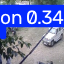

In [68]:
import matplotlib.pyplot as plt

test_vid_name = list(all_video_indexes["Stealing"].keys())[0]
frame_list = all_video_indexes["Stealing"][test_vid_name]

# pick a frame roughly in the middle of the video
mid_frame_path = frame_list[len(frame_list)//2][1]
print(mid_frame_path)

results = yolo_model(mid_frame_path)
results[0].show()  # displays image with boxes drawn

In [69]:
for box in results[0].boxes:
    cls_id = int(box.cls[0])
    cls_name = yolo_model.names[cls_id]
    conf = float(box.conf[0])
    xyxy = box.xyxy[0].tolist()
    print(f"{cls_name}  conf={conf:.2f}  bbox={xyxy}")

person  conf=0.34  bbox=[1.044927954673767, 26.560272216796875, 4.8706560134887695, 37.62107467651367]


Image size: (64, 64)


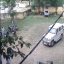

In [70]:
from PIL import Image
img = Image.open(mid_frame_path)
print("Image size:", img.size)  # (width, height)
img

In [71]:
results = yolo_model(mid_frame_path, conf=0.1)  # lower threshold to see marginal detections
for box in results[0].boxes:
    cls_id = int(box.cls[0])
    cls_name = yolo_model.names[cls_id]
    conf = float(box.conf[0])
    xyxy = box.xyxy[0].tolist()
    print(f"{cls_name}  conf={conf:.2f}  bbox={xyxy}")


image 1/1 /root/.cache/kagglehub/datasets/odins0n/ucf-crime-dataset/versions/1/Train/Stealing/Stealing077_x264_9590.png: 640x640 2 persons, 1 car, 1 truck, 1 bench, 15.1ms
Speed: 4.4ms preprocess, 15.1ms inference, 8.4ms postprocess per image at shape (1, 3, 640, 640)
person  conf=0.34  bbox=[1.044927954673767, 26.560272216796875, 4.8706560134887695, 37.62107467651367]
car  conf=0.21  bbox=[43.86077880859375, 8.912398338317871, 49.8177490234375, 16.742752075195312]
truck  conf=0.13  bbox=[43.90982437133789, 8.694398880004883, 49.9148063659668, 16.781862258911133]
bench  conf=0.12  bbox=[11.951825141906738, 7.489778995513916, 31.01676368713379, 18.135995864868164]
person  conf=0.12  bbox=[5.647757053375244, 26.776844024658203, 10.36338996887207, 37.1544303894043]


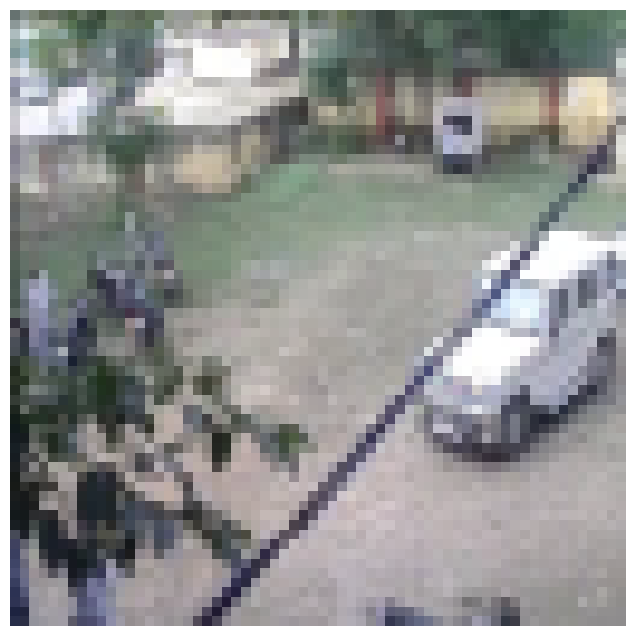

In [72]:
import matplotlib.pyplot as plt
img = Image.open(mid_frame_path)
plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis('off')
plt.show()

In [73]:
from PIL import Image
img = Image.open(mid_frame_path)
print("Original size:", img.size)

img_upscaled = img.resize((img.width * 4, img.height * 4), Image.LANCZOS)
print("Upscaled size:", img_upscaled.size)

results = yolo_model(img_upscaled, conf=0.1)
for box in results[0].boxes:
    cls_id = int(box.cls[0])
    cls_name = yolo_model.names[cls_id]
    conf = float(box.conf[0])
    xyxy = box.xyxy[0].tolist()
    print(f"{cls_name}  conf={conf:.2f}  bbox={xyxy}")

Original size: (64, 64)
Upscaled size: (256, 256)

0: 640x640 1 car, 17.7ms
Speed: 4.9ms preprocess, 17.7ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 640)
car  conf=0.25  bbox=[176.07164001464844, 25.168798446655273, 199.67349243164062, 67.35594940185547]


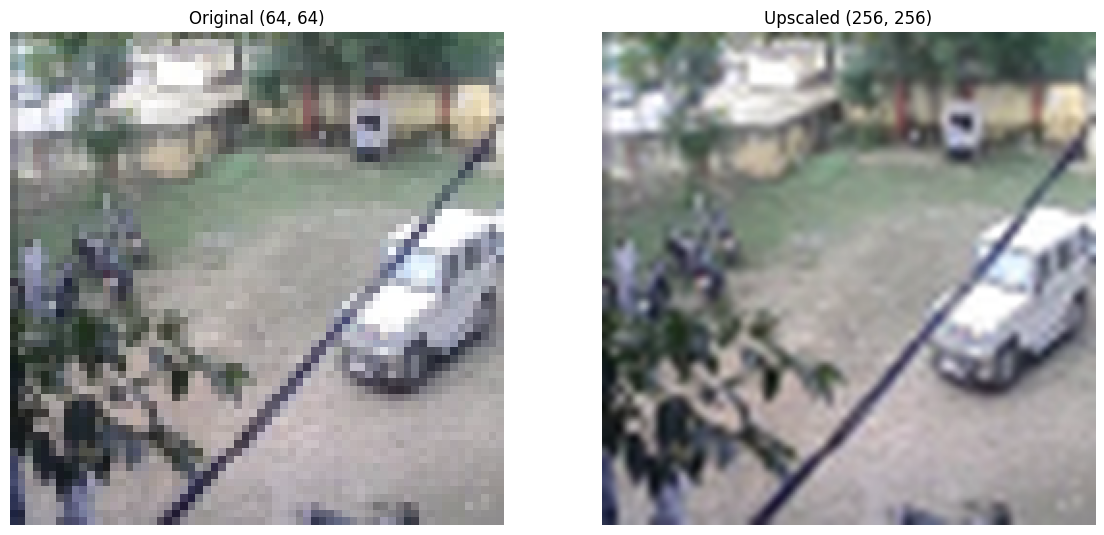

In [74]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14,7))
axes[0].imshow(img)
axes[0].set_title(f"Original {img.size}")
axes[0].axis('off')

axes[1].imshow(img_upscaled)
axes[1].set_title(f"Upscaled {img_upscaled.size}")
axes[1].axis('off')
plt.show()

In [76]:
for box in results[0].boxes:
    cls_id = int(box.cls[0])
    cls_name = yolo_model.names[cls_id]
    conf = float(box.conf[0])
    print(f"{cls_name}  conf={conf:.2f}")

car  conf=0.25


In [77]:
def load_and_upscale(path, scale=4):
    img = Image.open(path).convert("RGB")
    return img.resize((img.width*scale, img.height*scale), Image.LANCZOS)

In [78]:
results = yolo_model(img_upscaled, conf=0.05)  # very low threshold to see everything
print(f"Total detections: {len(results[0].boxes)}")
for box in results[0].boxes:
    cls_id = int(box.cls[0])
    cls_name = yolo_model.names[cls_id]
    conf = float(box.conf[0])
    xyxy = box.xyxy[0].tolist()
    print(f"{cls_name}  conf={conf:.2f}  bbox={xyxy}")


0: 640x640 1 person, 1 car, 1 truck, 1 bird, 16.5ms
Speed: 7.1ms preprocess, 16.5ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 640)
Total detections: 4
car  conf=0.25  bbox=[176.07164001464844, 25.168798446655273, 199.67349243164062, 67.35594940185547]
person  conf=0.09  bbox=[176.12486267089844, 25.026477813720703, 199.923095703125, 67.18804168701172]
truck  conf=0.07  bbox=[176.1388397216797, 24.878284454345703, 200.31105041503906, 67.33795928955078]
bird  conf=0.06  bbox=[43.79754638671875, 170.2462615966797, 104.37566375732422, 230.0997772216797]


In [80]:
!pip install yt-dlp --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.7/183.7 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 87.6 MB/s eta 0:00:00


In [115]:
from google.colab import files
uploaded = files.upload()

Saving IMG_1305.mov to IMG_1305.mov


In [128]:
from decord import VideoReader
vr = VideoReader('/content/IMG_1305.mov')  # update filename
print("Total frames:", len(vr), "FPS:", vr.get_avg_fps())
print("Frame shape:", vr[0].asnumpy().shape)

Total frames: 379 FPS: 29.452143504727367
Frame shape: (1080, 1920, 3)


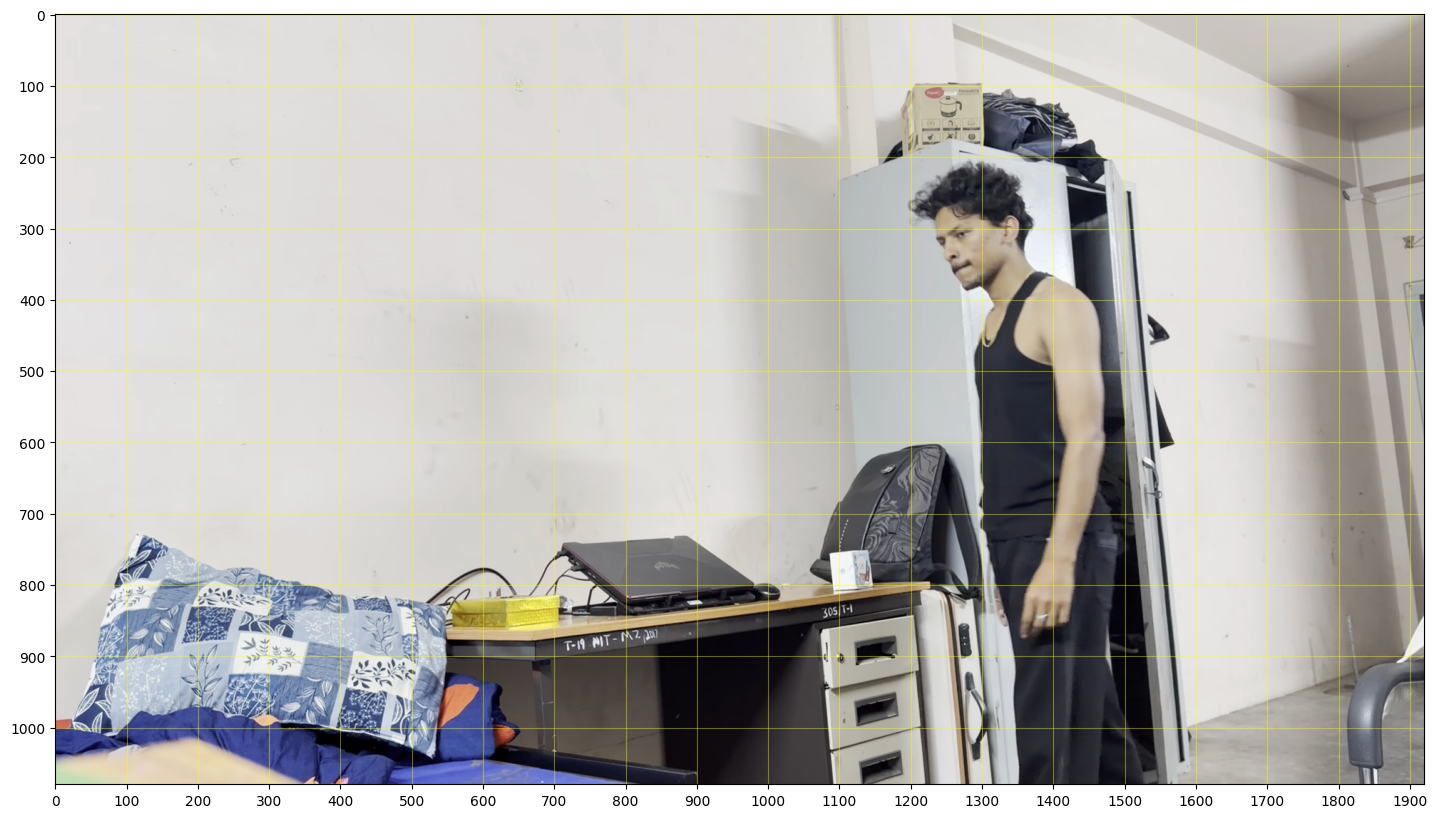

In [129]:
import matplotlib.pyplot as plt
import numpy as np

frame = vr[len(vr)//2].asnumpy()
plt.figure(figsize=(18,10))
plt.imshow(frame)
plt.xticks(np.arange(0, frame.shape[1], 100))
plt.yticks(np.arange(0, frame.shape[0], 100))
plt.grid(color='yellow', alpha=0.4)
plt.show()


In [130]:
start, end, step = 0, len(vr), 3  # every 3rd frame, whole clip
tracks = track_over_range(vr, start, end, step, yolo_model)

print(f"{len(tracks)} tracks found")
for tid, entries in tracks.items():
    cls_name = entries[0][1]
    print(f"Track {tid}: class={cls_name}, n_detections={len(entries)}, frames={entries[0][0]}-{entries[-1][0]}")

8 tracks found
Track 86: class=laptop, n_detections=96, frames=0-375
Track 87: class=person, n_detections=79, frames=0-378
Track 90: class=person, n_detections=113, frames=39-378
Track 91: class=person, n_detections=4, frames=42-54
Track 96: class=person, n_detections=2, frames=54-57
Track 100: class=refrigerator, n_detections=3, frames=168-174
Track 103: class=cup, n_detections=11, frames=195-246
Track 107: class=refrigerator, n_detections=11, frames=300-378


In [131]:
zones = {
    "ShelfZone": [400, 500, 1000, 950],   # desk with laptop + backpack
    "ExitZone":  [1550, 0, 1920, 1080],   # right side, toward the door
}

In [132]:
dwell_times = compute_dwell_times(tracks, zones)
for tid, zc in dwell_times.items():
    print(f"person_{tid}: {zc}")

person_87: {'ExitZone': 15.8}
person_90: {'ExitZone': 9.0, 'ShelfZone': 1.4}
person_91: {'ExitZone': 0.8}
person_96: {'ExitZone': 0.4}


In [133]:
# near-relations with the laptop
G = nx.MultiDiGraph()
person_tracks = {tid: e for tid, e in tracks.items() if e[0][1] == "person"}
object_tracks = {tid: e for tid, e in tracks.items() if e[0][1] != "person"}

for ptid, pentries in person_tracks.items():
    for otid, oentries in object_tracks.items():
        p_frames = {f[0]: f[3] for f in pentries}
        o_frames = {f[0]: f[3] for f in oentries}
        shared_frames = set(p_frames) & set(o_frames)
        for fr in shared_frames:
            if iou(p_frames[fr], o_frames[fr]) > 0.0:
                cls_name = oentries[0][1]
                G.add_edge(f"person_{ptid}", f"{cls_name}_{otid}", relation="near", frame=fr)

for u, v, data in G.edges(data=True):
    print(u, "->", v, data)

person_90 -> laptop_86 {'relation': 'near', 'frame': 375}
person_90 -> refrigerator_100 {'relation': 'near', 'frame': 168}
person_90 -> refrigerator_100 {'relation': 'near', 'frame': 171}
person_90 -> refrigerator_100 {'relation': 'near', 'frame': 174}
person_90 -> cup_103 {'relation': 'near', 'frame': 225}
person_90 -> cup_103 {'relation': 'near', 'frame': 198}
person_90 -> cup_103 {'relation': 'near', 'frame': 201}
person_90 -> cup_103 {'relation': 'near', 'frame': 204}
person_90 -> cup_103 {'relation': 'near', 'frame': 207}
person_90 -> cup_103 {'relation': 'near', 'frame': 243}
person_90 -> cup_103 {'relation': 'near', 'frame': 246}
person_90 -> cup_103 {'relation': 'near', 'frame': 216}
person_90 -> cup_103 {'relation': 'near', 'frame': 219}
person_90 -> cup_103 {'relation': 'near', 'frame': 222}
person_90 -> refrigerator_107 {'relation': 'near', 'frame': 354}
person_90 -> refrigerator_107 {'relation': 'near', 'frame': 360}
person_90 -> refrigerator_107 {'relation': 'near', 'frame

In [134]:
# zone transitions over time for the main tracks
for tid in [87, 90]:
    entries = tracks[tid]
    print(f"\nTrack {tid} zone-by-frame:")
    for frame_idx, cls_name, conf, bbox in entries[::5]:
        cx, cy = bbox_center(bbox)
        z = zone_for_point(cx, cy, zones)
        print(f"  frame {frame_idx}: zone={z}")


Track 87 zone-by-frame:
  frame 0: zone=ExitZone
  frame 87: zone=ExitZone
  frame 126: zone=ExitZone
  frame 180: zone=ExitZone
  frame 195: zone=ExitZone
  frame 210: zone=ExitZone
  frame 225: zone=ExitZone
  frame 240: zone=ExitZone
  frame 258: zone=ExitZone
  frame 273: zone=ExitZone
  frame 288: zone=ExitZone
  frame 303: zone=ExitZone
  frame 318: zone=ExitZone
  frame 333: zone=ExitZone
  frame 348: zone=ExitZone
  frame 363: zone=ExitZone

Track 90 zone-by-frame:
  frame 39: zone=ExitZone
  frame 54: zone=ExitZone
  frame 69: zone=ExitZone
  frame 84: zone=ExitZone
  frame 99: zone=ExitZone
  frame 114: zone=ExitZone
  frame 129: zone=ExitZone
  frame 144: zone=ExitZone
  frame 159: zone=ExitZone
  frame 174: zone=None
  frame 189: zone=None
  frame 204: zone=None
  frame 222: zone=None
  frame 237: zone=None
  frame 252: zone=None
  frame 267: zone=None
  frame 282: zone=None
  frame 297: zone=None
  frame 312: zone=None
  frame 327: zone=None
  frame 342: zone=None
  frame

In [136]:
def check_theft_pattern(tracks, zones, person_id, valid_object_classes={"laptop","backpack","handbag","cup","book","suitcase"}):
    entries = tracks[person_id]
    zone_sequence = []
    for frame_idx, cls_name, conf, bbox in entries:
        cx, cy = bbox_center(bbox)
        z = zone_for_point(cx, cy, zones)
        zone_sequence.append((frame_idx, z))

    was_near_shelf = any(z == "ShelfZone" for _, z in zone_sequence)
    ended_in_exit_or_moving = zone_sequence[-1][1] in ("ExitZone", None)

    had_object_contact = any(
        u == f"person_{person_id}" and v.split("_")[0] in valid_object_classes
        for u, v in G.edges()  # fixed: 2-tuples, no data
    )

    return {
        "was_near_shelf": was_near_shelf,
        "had_object_contact": had_object_contact,
        "final_zone": zone_sequence[-1][1],
        "flagged": was_near_shelf and had_object_contact
    }

result = check_theft_pattern(tracks, zones, 90)
print(result)

{'was_near_shelf': True, 'had_object_contact': True, 'final_zone': 'ShelfZone', 'flagged': True}


In [137]:
def fused_alert(vit_anomaly_score, kg_result, vit_threshold=0.5, w_vit=0.6, w_kg=0.4):
    kg_score = 1.0 if kg_result["flagged"] else 0.0
    final_score = w_vit * vit_anomaly_score + w_kg * kg_score

    explanation = []
    if vit_anomaly_score > vit_threshold:
        explanation.append(f"ViT anomaly score elevated ({vit_anomaly_score:.2f})")
    if kg_result["flagged"]:
        explanation.append(f"KG pattern match: near shelf={kg_result['was_near_shelf']}, object contact={kg_result['had_object_contact']}")

    return {
        "final_score": final_score,
        "alert": final_score > 0.5,
        "explanation": explanation
    }

# example: run your MIL head on this same clip's ViT features (if you extract them),
# or just test the fusion logic with a placeholder score for now
example = fused_alert(vit_anomaly_score=0.75, kg_result=result)
print(example)

{'final_score': 0.85, 'alert': True, 'explanation': ['ViT anomaly score elevated (0.75)', 'KG pattern match: near shelf=True, object contact=True']}


In [138]:
def extract_features_from_video(vr, model, processor, n_segments=32, frames_per_clip=16):
    total = len(vr)
    boundaries = np.linspace(0, total, n_segments + 1, dtype=int)
    features = []
    for i in range(n_segments):
        start, end = boundaries[i], max(boundaries[i+1], boundaries[i]+1)
        idx = np.linspace(start, end-1, frames_per_clip, dtype=int)
        idx = np.clip(idx, 0, total-1)
        clip_frames = vr.get_batch(idx).asnumpy()
        clip = [f for f in clip_frames]
        inputs = processor(clip, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            out = model(**inputs).last_hidden_state.mean(dim=1)
        features.append(out.squeeze(0).cpu())
    return torch.stack(features)

staged_clip_feat = extract_features_from_video(vr, model, processor)
print(staged_clip_feat.shape)  # expect (32, 768)

torch.Size([32, 768])


In [139]:
stealing_head = per_class_models["Stealing"]
stealing_head.eval()

with torch.no_grad():
    scores = stealing_head(staged_clip_feat.unsqueeze(0).to(device)).squeeze(0).cpu().numpy()

real_vit_score = float(scores.max())
print("Segment scores:", scores)
print("Max (bag-level) score:", real_vit_score)

Segment scores: [     0.1579     0.16064     0.16528     0.16468     0.16893     0.17032     0.16315     0.16751     0.16377     0.13349     0.16008     0.15093     0.10998     0.10137     0.10596     0.12222     0.10619     0.11352     0.11753     0.12323     0.12288     0.11677     0.12357     0.11021    0.096291    0.095455
     0.10851    0.099622    0.088167         0.1     0.13524     0.16077]
Max (bag-level) score: 0.17031826078891754


In [140]:
final = fused_alert(vit_anomaly_score=real_vit_score, kg_result=result)
print(final)

{'final_score': 0.5021909564733505, 'alert': True, 'explanation': ['KG pattern match: near shelf=True, object contact=True']}


In [141]:
def fused_alert_v2(vit_anomaly_score, kg_result, vit_threshold=0.5):
    kg_flagged = kg_result["flagged"]

    if kg_flagged and vit_anomaly_score > vit_threshold:
        level = "HIGH"
    elif kg_flagged:
        level = "MEDIUM"  # symbolic evidence alone
    elif vit_anomaly_score > vit_threshold:
        level = "MEDIUM"  # statistical evidence alone
    else:
        level = "LOW"

    return {"level": level, "vit_score": vit_anomaly_score, "kg_flagged": kg_flagged}